给定一个二元函数:z=3x1+2x2+1+ϵ
其中 ϵ 是均值为0、标准差为0.3的高斯噪声。
你需要：
生成训练数据集
使用 PyTorch 构建线性回归模型（使用 nn.Module）
使用均方误差损失函数
训练模型
使用 matplotlib 绘制训练损失曲线，并可视化模型拟合效果
将结果保存为图片

x 的形状: torch.Size([100, 1])
y 的形状: torch.Size([100, 1])
前5个样本点:
 x: tensor([0.0000, 0.1010, 0.2020, 0.3030, 0.4040])
 y: tensor([1.9635, 1.9457, 1.8544, 0.5533, 2.1473])
初始 w: 0.0000, 初始 b: 0.0000
Epoch [100/1000], Loss: 0.290928, w: 2.0636, b: 0.6021
Epoch [200/1000], Loss: 0.259282, w: 2.0375, b: 0.7756
Epoch [300/1000], Loss: 0.247584, w: 2.0216, b: 0.8811
Epoch [400/1000], Loss: 0.243261, w: 2.0120, b: 0.9452
Epoch [500/1000], Loss: 0.241663, w: 2.0061, b: 0.9842
Epoch [600/1000], Loss: 0.241072, w: 2.0026, b: 1.0079
Epoch [700/1000], Loss: 0.240854, w: 2.0004, b: 1.0223
Epoch [800/1000], Loss: 0.240773, w: 1.9991, b: 1.0310
Epoch [900/1000], Loss: 0.240743, w: 1.9983, b: 1.0364
Epoch [1000/1000], Loss: 0.240732, w: 1.9978, b: 1.0396

===== 训练完成 =====
真实的 w: 2.0, 学习到的 w: 1.9978
真实的 b: 1.0, 学习到的 b: 1.0396


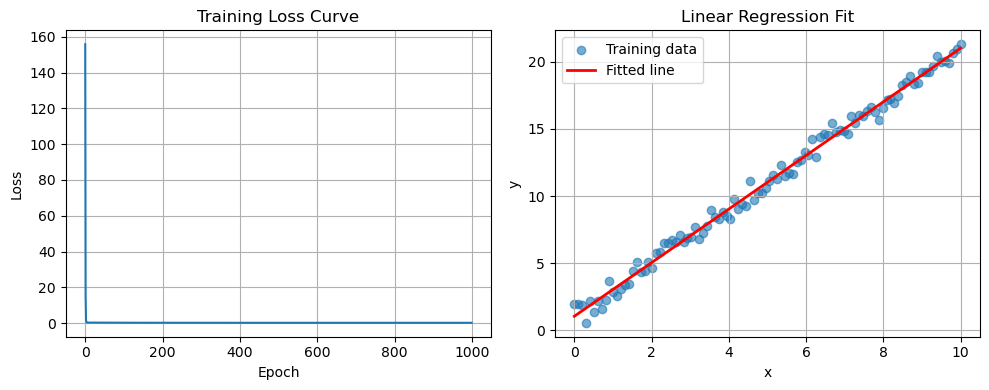

In [23]:
import torch
import numpy as np
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
%matplotlib inline
#内核容易跑崩，这一步ai给的
import matplotlib.pyplot as plt
torch.manual_seed(42)

# 生成100个样本点，真实关系为 y = 2x + 1 + 噪声
def generate_data(n_samples=100):
    # 生成 x，范围在 [0, 10] 之间
    x = torch.linspace(0, 10, n_samples).reshape(-1, 1)
    # 真实的权重和偏置
    w_true = 2.0
    b_true = 1.0
    # 生成 y，加上高斯噪声
    noise = torch.randn(n_samples, 1) * 0.5
    y = w_true * x + b_true + noise
    return x, y

x_data, y_data = generate_data()

print(f"x 的形状: {x_data.shape}")
print(f"y 的形状: {y_data.shape}")
print(f"前5个样本点:\n x: {x_data[:5].flatten()}\n y: {y_data[:5].flatten()}")

# 初始化权重 w，形状为 (1, 1)，初始值为 0
w = torch.tensor([[0.]],)
# 初始化偏置 b，形状为 (1,)，初始值为 0
b = torch.tensor([0.])

print(f"初始 w: {w.item():.4f}, 初始 b: {b.item():.4f}")

def linear_model(x, w, b):
    """
    线性回归模型: y = w * x + b

    参数:
        x: 输入数据，形状为 (n_samples, 1)
        w: 权重，形状为 (1, 1)
        b: 偏置，形状为 (1,)

    返回:
        预测值，形状为 (n_samples, 1)
    """
    return x@w+b

def mse_loss(y_pred, y_true):
    """
    均方误差损失函数: L = (1/n) * Σ(y_pred - y_true)²

    参数:
        y_pred: 预测值，形状为 (n_samples, 1)
        y_true: 真实值，形状为 (n_samples, 1)

    返回:
        损失值，一个标量
    """
    return torch.sum((y_pred - y_true)**2)/len(y_pred)

def compute_gradients(x, y_true, y_pred):
    """
    计算损失函数对 w 和 b 的梯度。
    注意：这里我们不使用 PyTorch 的自动求导，而是手动实现梯度计算。

    提示：
        - 均方误差 L = (1/n) * Σ(y_pred - y_true)²
        - ∂L/∂w = (2/n) * Σ[(y_pred - y_true) * x]
        - ∂L/∂b = (2/n) * Σ[(y_pred - y_true)]

    参数:
        x: 输入数据，形状为 (n_samples, 1)
        y_true: 真实值，形状为 (n_samples, 1)
        y_pred: 预测值，形状为 (n_samples, 1)

    返回:
        grad_w: 损失函数对 w 的梯度
        grad_b: 损失函数对 b 的梯度
    """
    n = x.shape[0]  # 样本数量

    # 计算预测值与真实值的差值
    diff = torch.sum(y_pred - y_true)

    # 计算梯度（注意形状匹配）
    grad_w = torch.sum((y_pred - y_true)*x)*2/len(y_pred)
    grad_b = torch.sum(y_pred - y_true)*2/len(y_pred)

    return grad_w, grad_b

def update_parameters(w, b, grad_w, grad_b, learning_rate):
    """
    使用梯度下降更新参数
    w_new = w - lr * grad_w
    b_new = b - lr * grad_b

    参数:
        w: 当前权重
        b: 当前偏置
        grad_w: w 的梯度
        grad_b: b 的梯度
        learning_rate: 学习率

    返回:
        更新后的 w 和 b
    """
    w_new = w - learning_rate*grad_w
    b_new = b - learning_rate*grad_b
    return w_new, b_new

def train(x, y, w, b, learning_rate, num_epochs):
    """
    训练线性回归模型

    参数:
        x: 训练数据
        y: 目标值
        w: 初始权重
        b: 初始偏置
        learning_rate: 学习率
        num_epochs: 训练轮数

    返回:
        训练过程中的损失记录, 训练好的 w 和 b
    """
    losses = []

    for epoch in range(num_epochs):
        # 1. 前向传播：计算预测值
        y_pred = linear_model(x, w, b)

        # 2. 计算损失
        loss = mse_loss(y_pred, y)
        losses.append(loss.item())

        # 3. 计算梯度
        grad_w, grad_b = compute_gradients(x, y, y_pred)

        # 4. 更新参数
        w, b = update_parameters(w, b, grad_w, grad_b, learning_rate)

        # 5. 每100轮打印一次损失
        if (epoch + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.6f}, w: {w.item():.4f}, b: {b.item():.4f}')

    return losses, w, b

# 设置超参数
learning_rate = 0.01
num_epochs = 1000

# 开始训练
losses, w_trained, b_trained = train(x_data, y_data, w, b, learning_rate, num_epochs)

print("\n===== 训练完成 =====")
print(f"真实的 w: 2.0, 学习到的 w: {w_trained.item():.4f}")
print(f"真实的 b: 1.0, 学习到的 b: {b_trained.item():.4f}")

# 绘制损失下降曲线
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.grid(True)

# 绘制拟合结果
plt.subplot(1, 2, 2)
plt.scatter(x_data.numpy(), y_data.numpy(), alpha=0.6, label='Training data')
plt.plot(x_data.numpy(), (w_trained * x_data + b_trained).numpy(),
         color='red', linewidth=2, label='Fitted line')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression Fit')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('./images/linear_regression_manual_result1.png', dpi=150)
plt.show()
plt.close()

#这里用plt.show()内核终是跑崩，ai提示用的plt.close,但之后show又能跑通


生成训练数据集
使用 PyTorch 构建线性回归模型（使用 nn.Module）
使用均方误差损失函数
训练模型
使用 matplotlib 绘制训练损失曲线，并可视化模型拟合效果
将结果保存为图片

#这里是手写求梯度

Epoch [100/10000], Loss: 0.292379, w1: 1.9821, w12: 1.1499,b: 0.2955
Epoch [200/10000], Loss: 0.156066, w1: 2.0491, w12: 1.0689,b: 0.3179
Epoch [300/10000], Loss: 0.143393, w1: 2.0638, w12: 1.0480,b: 0.3402
Epoch [400/10000], Loss: 0.138141, w1: 2.0658, w12: 1.0416,b: 0.3619
Epoch [500/10000], Loss: 0.133594, w1: 2.0650, w12: 1.0387,b: 0.3830
Epoch [600/10000], Loss: 0.129346, w1: 2.0634, w12: 1.0367,b: 0.4035
Epoch [700/10000], Loss: 0.125359, w1: 2.0618, w12: 1.0349,b: 0.4233
Epoch [800/10000], Loss: 0.121615, w1: 2.0601, w12: 1.0332,b: 0.4425
Epoch [900/10000], Loss: 0.118101, w1: 2.0585, w12: 1.0316,b: 0.4611
Epoch [1000/10000], Loss: 0.114800, w1: 2.0569, w12: 1.0301,b: 0.4791
Epoch [1100/10000], Loss: 0.111701, w1: 2.0554, w12: 1.0285,b: 0.4966
Epoch [1200/10000], Loss: 0.108792, w1: 2.0540, w12: 1.0271,b: 0.5135
Epoch [1300/10000], Loss: 0.106060, w1: 2.0525, w12: 1.0257,b: 0.5299
Epoch [1400/10000], Loss: 0.103494, w1: 2.0511, w12: 1.0243,b: 0.5458
Epoch [1500/10000], Loss: 0.1

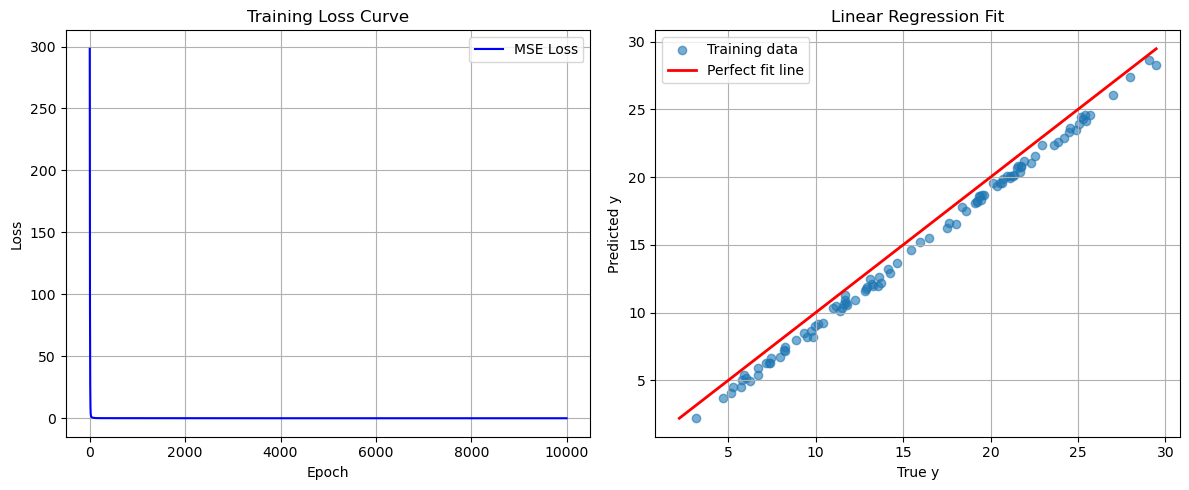

In [33]:
import torch
import numpy as np
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
%matplotlib inline
import matplotlib.pyplot as plt
torch.manual_seed(42)

from torch import nn

def generate(n_numble):
    #x1 = torch.linspace(0, 10, n_numble).reshape(-1, 1)
    #x2 = torch.linspace(2, 12, n_numble).reshape(-1, 1)
    #梯度下降始终卡住，问的ai，两个输入一模一样，分不清到底是 w1 贡献还是 w2 贡献
    #w1,w2始终成线性关系，改为随机生成
    x1 = 10 * torch.rand(n_numble,1)
    x2 = 10 * torch.rand(n_numble,1)
    
    # 按列拼接，这步是问的ai，知道forward只能传一个参数
    x = torch.cat([x1, x2], dim=1)
    w1_true = 2.0
    w2_true = 1.0
    noise = torch.randn(n_numble,1) * 0.3
    y_true = w1_true * x1 + w2_true * x2 + 1 + noise
    return x, y_true

def model(x,y_true,w1,w2,b):
    x1 = x[:,0:1]
    x2 = x[:,1:2] 
    y_pred = w1*x1 + w2*x2 + b
    loss = torch.sum((y_pred - y_true)**2)/len(y_pred)
    grad_w1 = torch.sum((y_pred - y_true)*x1)*2/len(y_pred)
    grad_w2 = torch.sum((y_pred - y_true)*x2)*2/len(y_pred)
    grad_b = torch.sum(y_pred - y_true)*2/len(y_pred)
    return loss,grad_w1,grad_w2,grad_b

def update_parameters(w1, w2, b,grad_w1, grad_w2, grad_b,learning_rate):
    w1 = w1 - learning_rate*grad_w1
    w2 = w2 - learning_rate*grad_w2
    b = b - learning_rate*grad_b

    return w1, w2,b

def train(x, y_true, w1, w2, b,learning_rate, num_epochs):
    losses = []

    for epoch in range(num_epochs):
        loss,grad_w1, grad_w2,grad_b = model(x, y_true,w1,w2,b )
        losses.append(loss.item())

        w1, w2,b = update_parameters(w1, w2, b, grad_w1, grad_w2, grad_b,learning_rate)

        if (epoch + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.6f}, w1: {w1.item():.4f}, w12: {w2.item():.4f},b: {b.item():.4f}')

    return losses, w1,w2, b
learning_rate = 0.001
num_epochs = 10000
n_numble = 100
x,y_true = generate(n_numble)
w1 = torch.tensor(0.0)
w2 = torch.tensor(0.0)
#这里ai提示张量广播叠加时可能使数值爆炸，于是改成标量
b = torch.tensor(0.0)

losses, w1_trained, w2_trained,b_trained = train(x, y_true, w1, w2,b, learning_rate, num_epochs)
print(w1_trained, w2_trained,b_trained)

y_pred = w1_trained*x[:,0:1] + w2_trained*x[:,1:2] + b
plt.figure(figsize=(12, 5))

#左图
plt.subplot(1, 2, 1)
plt.plot(losses, color='blue', linewidth=1.5, label='MSE Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()
plt.grid(True)

#右图
plt.subplot(1, 2, 2)
plt.scatter(y_true.numpy(), y_pred.numpy(), alpha=0.6, label='Training data')
min_val = min(y_true.min().item(), y_pred.min().item())
max_val = max(y_true.max().item(), y_pred.max().item())
plt.plot([min_val, max_val], [min_val, max_val],
         color='red', linewidth=2, label='Perfect fit line')
plt.xlabel('True y')
plt.ylabel('Predicted y')
plt.title('Linear Regression Fit')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('./images/linear_regression_manual_result2.png', dpi=150)
plt.show()
plt.close()

#这里是自动求导

Parameter containing:
tensor([[0.4741, 0.6971]], requires_grad=True)
Parameter containing:
tensor([-0.1083], requires_grad=True)
Epoch [1000/10000], Loss: 0.145600, w1: 2.0700, w2: 1.0431, b: 0.3283
Epoch [2000/10000], Loss: 0.107482, w1: 2.0533, w2: 1.0264, b: 0.5213
Epoch [3000/10000], Loss: 0.087180, w1: 2.0411, w2: 1.0143, b: 0.6621
Epoch [4000/10000], Loss: 0.076367, w1: 2.0321, w2: 1.0054, b: 0.7649
Epoch [5000/10000], Loss: 0.070608, w1: 2.0256, w2: 0.9989, b: 0.8399
Epoch [6000/10000], Loss: 0.067541, w1: 2.0209, w2: 0.9942, b: 0.8946
Epoch [7000/10000], Loss: 0.065907, w1: 2.0174, w2: 0.9907, b: 0.9345
Epoch [8000/10000], Loss: 0.065037, w1: 2.0149, w2: 0.9882, b: 0.9637
Epoch [9000/10000], Loss: 0.064574, w1: 2.0130, w2: 0.9864, b: 0.9850
Epoch [10000/10000], Loss: 0.064327, w1: 2.0117, w2: 0.9850, b: 1.0005
w1 = 2.0117
w2 = 0.9850
b  = 1.0005


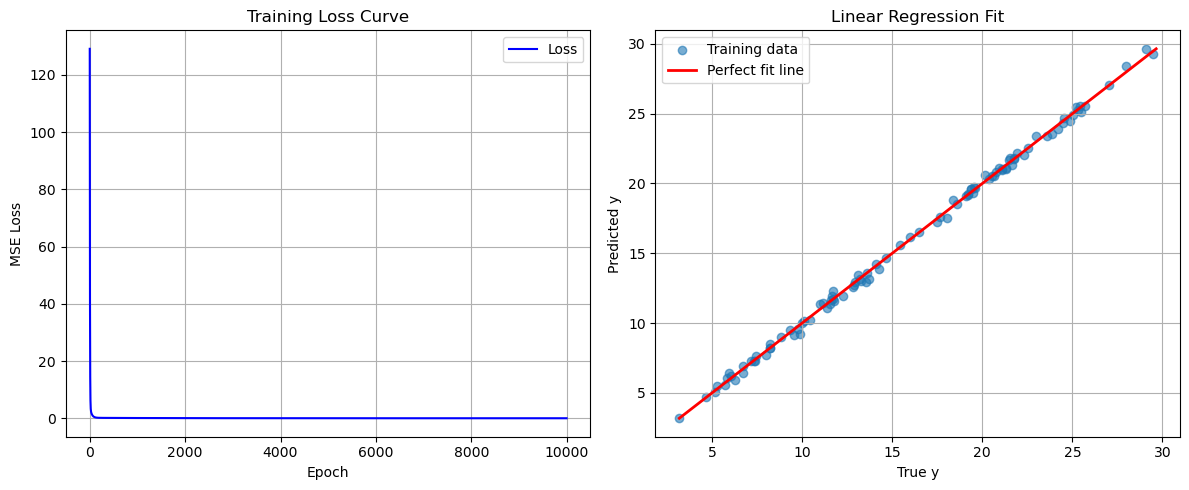

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
%matplotlib inline

torch.manual_seed(42)

# ========== 1. 生成数据集 ==========
def generate(n_numble):
    x1 = 10 * torch.rand(n_numble, 1)
    x2 = 10 * torch.rand(n_numble, 1)
    x = torch.cat([x1, x2], dim=1)  
    w1_true = 2.0
    w2_true = 1.0
    noise = torch.randn(n_numble, 1) * 0.3
    y_true = w1_true * x1 + w2_true * x2 + 1 + noise 
    return x, y_true

x, y_true = generate(n_numble)

class ZW(nn.Module):
    def __init__(self, input_dim=2, output_dim=1):
        #这里2对应w1和w2,1对应一个偏置b
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)
    
    def forward(self, x):
        return self.linear(x)


num_epochs = 10000
n_numble = 100

model = ZW()
#下面两步是ai优化过的，原本又是手动求的
mseloss = nn.MSELoss()  # 均方误差损失，和你手写的 sum/n 完全等价
optimizer = torch.optim.SGD(model.parameters(), lr = 0.001)  # SGD 梯度下降

print(model.linear.weight)
print(model.linear.bias)

losses = []

for epoch in range(num_epochs):
    optimizer.zero_grad()
    y_pred = model(x)
    loss = mseloss(y_pred, y_true)
    loss.backward()
    #参数更新，不用再手动了(doge)
    optimizer.step()
    
    losses.append(loss.item())
    
    if (epoch + 1) % 1000 == 0:
        w = model.linear.weight
        b = model.linear.bias
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.6f}, '
              f'w1: {w[0,0].item():.4f}, w2: {w[0,1].item():.4f}, b: {b.item():.4f}')

w = model.linear.weight
b = model.linear.bias
w1_trained = w[0, 0].item()
w2_trained = w[0, 1].item()
b_trained = b.item()

print(f"w1 = {w1_trained:.4f}")
print(f"w2 = {w2_trained:.4f}")
print(f"b  = {b_trained:.4f}")

y_pred_np = model(x).detach().numpy()
y_true_np = y_true.numpy()

plt.figure(figsize=(12, 5))

# 左图
plt.subplot(1, 2, 1)
plt.plot(losses, color='blue', label='Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss Curve')
plt.legend()
plt.grid(True)

# 右图
plt.subplot(1, 2, 2)
plt.scatter(y_true_np, y_pred_np, alpha=0.6, label='Training data')
min_val = min(y_true_np.min(), y_pred_np.min())
max_val = max(y_true_np.max(), y_pred_np.max())
plt.plot([min_val, max_val], [min_val, max_val],
         color='red', linewidth=2, label='Perfect fit line')
plt.xlabel('True y')
plt.ylabel('Predicted y')
plt.title('Linear Regression Fit')
plt.legend()
plt.grid(True)

plt.tight_layout()
os.makedirs('./images', exist_ok=True)
plt.savefig('./images/linear_regression_manual_result3.png', dpi=150)
plt.show()
plt.close()